# 全局样式设置

In [2]:
import os
import re
import json
import ast
import warnings
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# 中文显示
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 统一样式
sns.set_theme(
    style="whitegrid",
    font="SimHei",
    rc={
        "axes.unicode_minus": False,
        "figure.dpi": 130,
        "axes.facecolor": "#FAFAFA",
        "figure.facecolor": "white",
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--"
    }
)

In [3]:
# ============================================================
# 连接数据库并读取整表
# ============================================================

MYSQL_CONFIG = {
    "host": "127.0.0.1",
    "port": 3306,
    "user": "root",
    "password": "123456",
    "database": "shixiseng_db",
    "charset": "utf8mb4"
}

TABLE_NAME = "processed_job_details"

engine = create_engine(
    f"mysql+pymysql://{MYSQL_CONFIG['user']}:{MYSQL_CONFIG['password']}"
    f"@{MYSQL_CONFIG['host']}:{MYSQL_CONFIG['port']}/{MYSQL_CONFIG['database']}"
    f"?charset={MYSQL_CONFIG['charset']}"
)

df = pd.read_sql_table(TABLE_NAME, con=engine)

print(f"数据读取完成：{df.shape[0]} 行，{df.shape[1]} 列")
df.head()

数据读取完成：172063 行，19 列


,group_name,item_text,job_title_detail,publish_time_detail,city_detail,degree_detail,deadline_detail,company_name_detail,industry_detail,company_nature_detail,company_size_detail,company_location_detail,is_urgent_hire,job_tags,is_salary_negotiable,salary_min_per_day,salary_max_per_day,internship_months,days_per_week
0,产品,产品助理,产品助理,2026-01-06 22:29:06,南京,本科,2026-10-24,丁丁停车,互联网/游戏/软件,民营企业,50-150人,江苏,0,"[""可转正实习"", ""接受大一大二"", ""零基础实习"", ""提供免费住宿"", ""一对一导师""...",0,150.0,300.0,3,4
1,产品,产品,产品经理,2026-03-18 17:30:13,上海,本科,2026-06-23,淘宝闪购,互联网/游戏/软件,民营企业,2000人以上,上海市/上海,1,"[""周末双休""]",1,NaN,NaN,3,5
2,产品,产品经理,产品经理,2026-03-18 17:30:13,上海,本科,2026-06-23,淘宝闪购,互联网/游戏/软件,民营企业,2000人以上,上海市/上海,1,"[""周末双休""]",1,NaN,NaN,3,5
3,产品,产品设计,产品设计实习生,2026-03-20 14:14:11,北京,本科,2026-05-30,知乎,互联网/游戏/软件,民营企业,2000人以上,北京市,0,"[""学习机会多"", ""成长空间大"", ""免费三餐""]",0,120.0,150.0,3,5
4,产品,产品助理,产品助理实习生,2026-03-09 11:20:00,广州,本科,2026-09-05,ChatLabs,互联网/游戏/软件,民营企业,50-150人,广东/广州,0,"[""地铁周边"", ""周末双休"", ""一对一导师"", ""留学生实习"", ""节日福利"", ""产品...",0,120.0,140.0,3,4


# 岗位方向数量分布

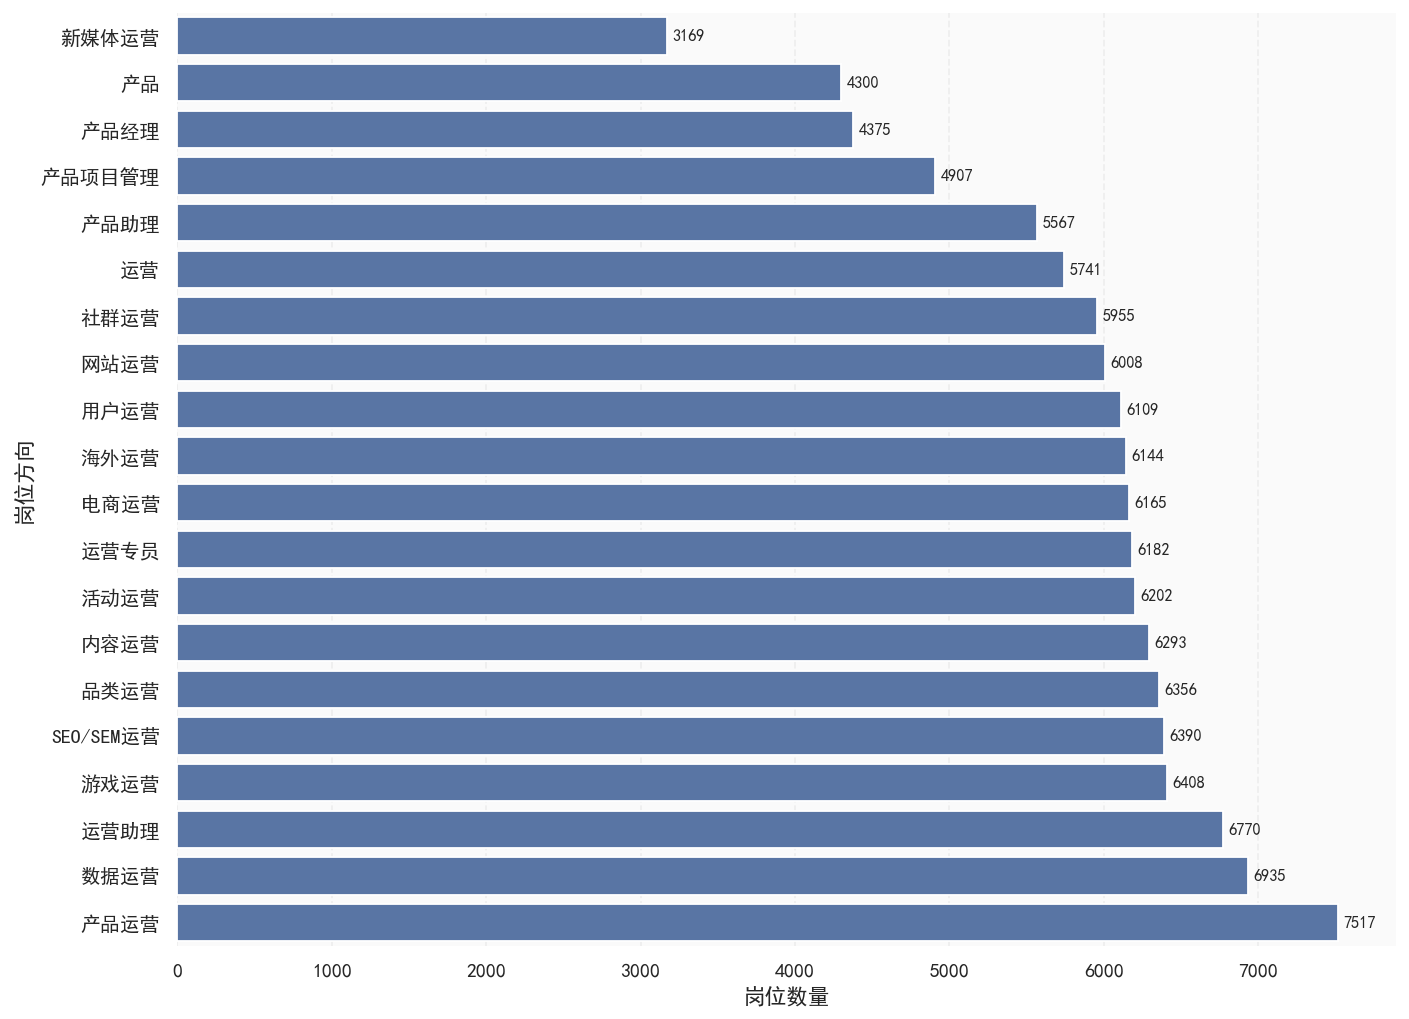

In [5]:
df["item_text"] = df["item_text"].fillna("").astype(str).str.strip()

df_job_direction = (
    df[df["item_text"] != ""].groupby("item_text", as_index=False).size()
    .rename(columns={"item_text": "岗位方向", "size": "岗位数量"}).sort_values("岗位数量", ascending=False).head(20)
)

df_plot = df_job_direction.sort_values("岗位数量", ascending=True)

plt.figure(figsize=(11, 8))

ax = sns.barplot(data=df_plot, x="岗位数量", y="岗位方向", color="#4C72B0")

for container in ax.containers:
    ax.bar_label(container, fmt="{:.0f}", padding=3, fontsize=9)

# plt.title("不同岗位方向岗位数量分布", fontsize=17, fontweight="bold", pad=15)
plt.xlabel("岗位数量", fontsize=12)
plt.ylabel("岗位方向", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.35)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 城市岗位分布

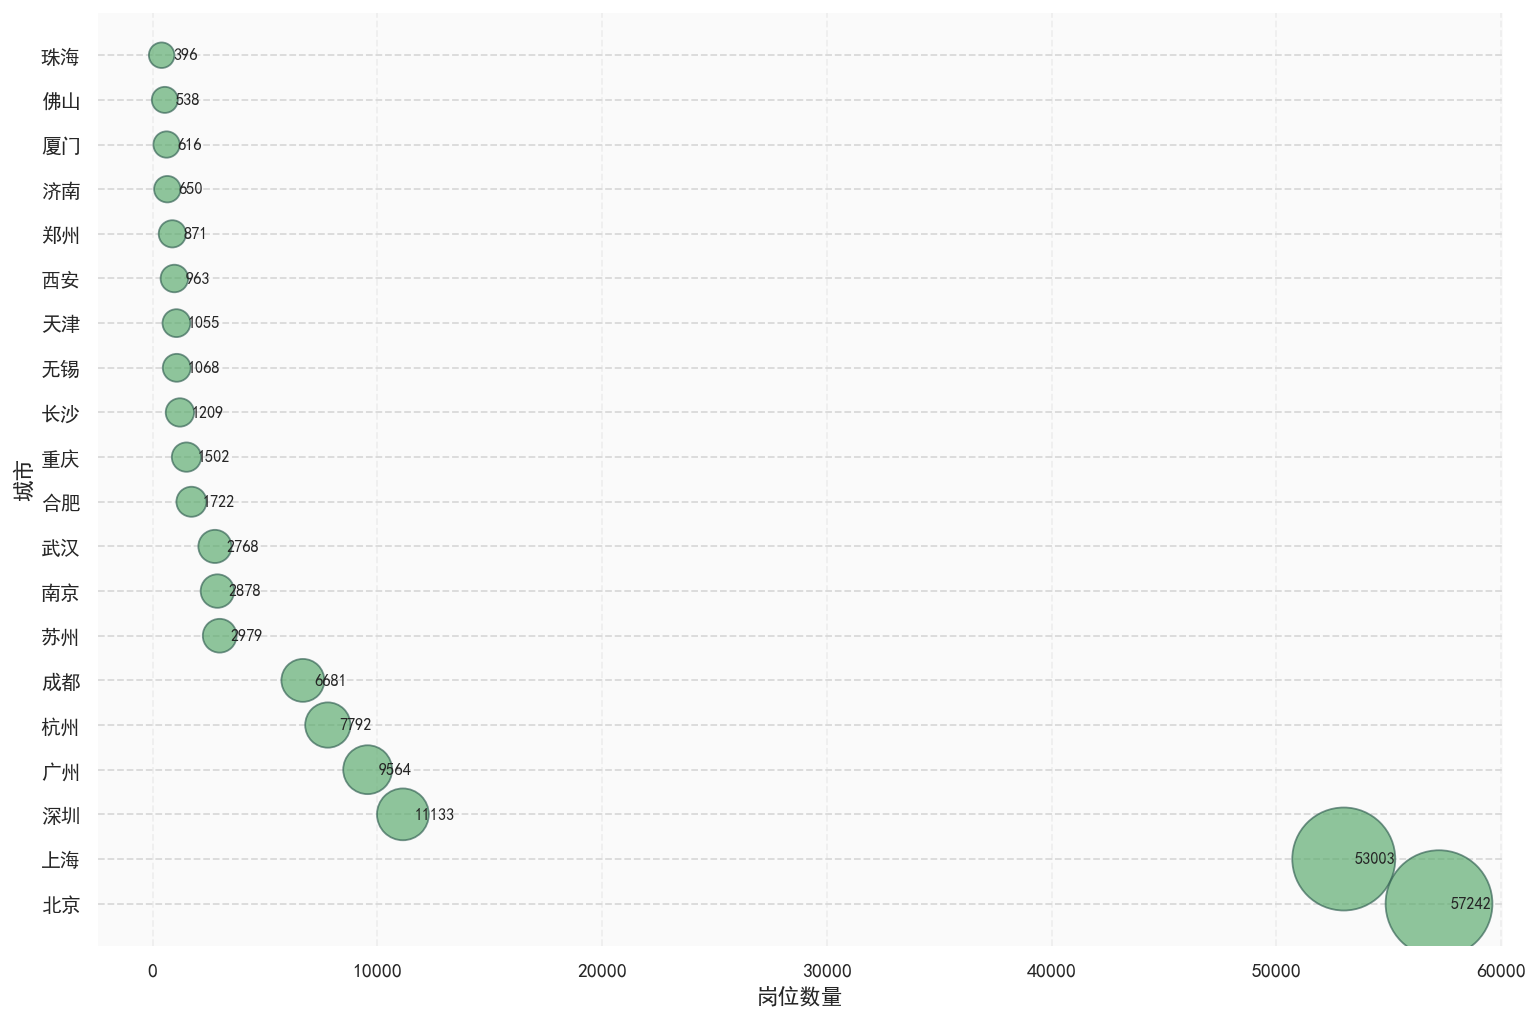

In [7]:
df["city_detail"] = df["city_detail"].fillna("").astype(str).str.strip()

df_city = (
    df[(df["city_detail"] != "") & (df["city_detail"] != "全国")].groupby("city_detail", as_index=False).size()
    .rename(columns={"city_detail": "城市", "size": "岗位数量"}).sort_values("岗位数量", ascending=False).head(20)
)

df_plot = df_city.sort_values("岗位数量", ascending=True).copy()

plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=df_plot, x="岗位数量", y="城市", size="岗位数量", sizes=(200, 3500),
    alpha=0.65, color="#55A868", edgecolor="#2F5D50", linewidth=1, legend=False
)

for _, row in df_plot.iterrows():
    ax.text(row["岗位数量"] + 500, row["城市"], f"{int(row['岗位数量'])}", va="center", fontsize=9)

# plt.title("互联网 IT 类实习岗位城市分布气泡图", fontsize=17, fontweight="bold", pad=15)
plt.xlabel("岗位数量", fontsize=12)
plt.ylabel("城市", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.35)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 技能关键词分布

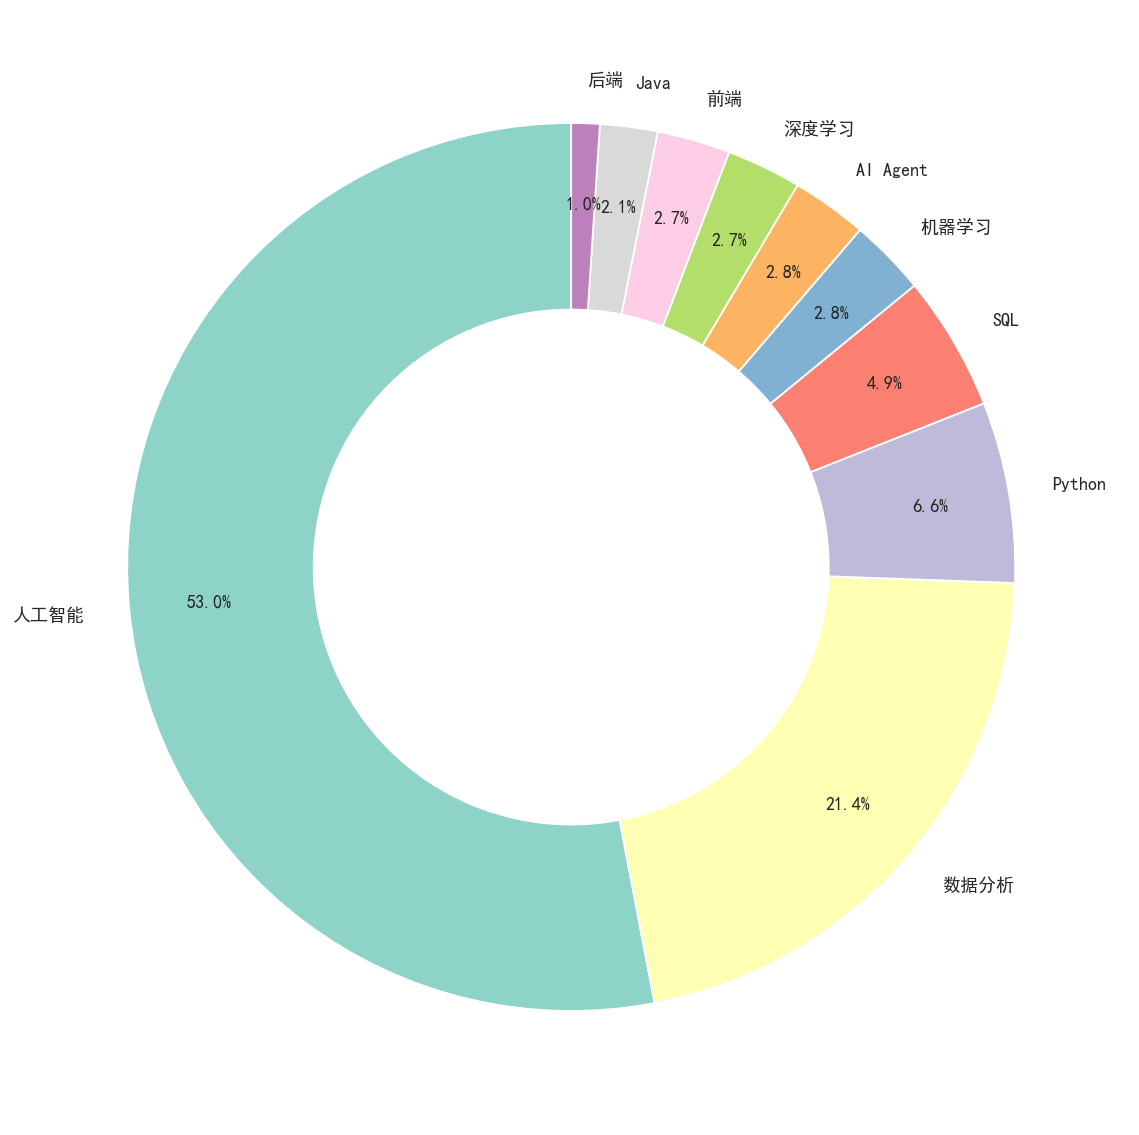

In [9]:
df["job_tags"] = df["job_tags"].fillna("").astype(str).str.strip()

skill_patterns = {
    "人工智能": ["人工智能", "AI"],
    "数据分析": ["数据分析"],
    "Python": ["Python", "python"],
    "SQL": ["SQL", "sql"],
    "机器学习": ["机器学习"],
    "AI Agent": ["AI Agent", "Agent", "agent"],
    "深度学习": ["深度学习"],
    "前端": ["前端", "HTML", "CSS", "JavaScript", "Vue", "React"],
    "Java": ["Java", "java"],
    "后端": ["后端"]
}

skill_rows = []

for skill_name, patterns in skill_patterns.items():
    pattern = "|".join([re.escape(p) for p in patterns])
    count = df["job_tags"].str.contains(pattern, case=False, regex=True, na=False).sum()
    skill_rows.append({"技能关键词": skill_name, "出现岗位数量": int(count)})

df_skill = (pd.DataFrame(skill_rows).sort_values("出现岗位数量", ascending=False).reset_index(drop=True))

plt.figure(figsize=(9, 9))

colors = sns.color_palette("Set3", n_colors=len(df_skill))

wedges, texts, autotexts = plt.pie(
    df_skill["出现岗位数量"], labels=df_skill["技能关键词"], autopct="%1.1f%%", startangle=90,
    pctdistance=0.82, textprops={"fontsize": 10}, colors=colors
)

centre_circle = plt.Circle((0, 0), 0.58, fc="white")
plt.gca().add_artist(centre_circle)

# plt.title("技能关键词占比环形图", fontsize=17, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# 急招分析

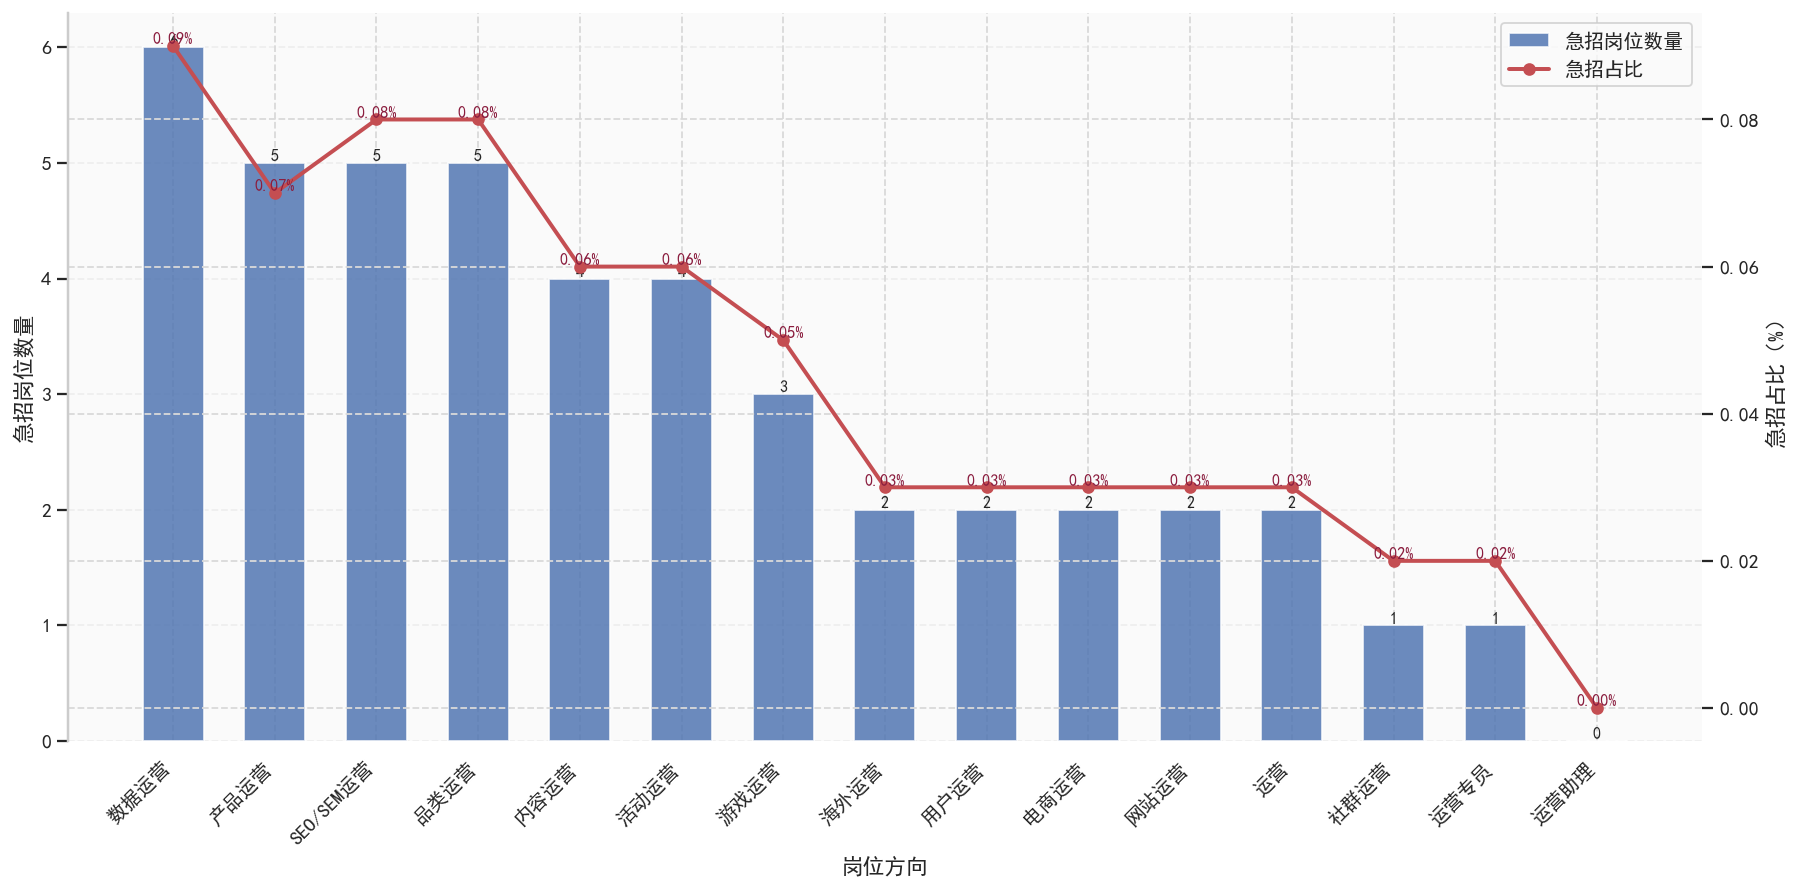

In [11]:
# 1. 急招字段转为数值型
df["is_urgent_hire"] = (pd.to_numeric(df["is_urgent_hire"], errors="coerce").fillna(0).astype(int))

# 2. 岗位方向字段清洗
df["item_text"] = (df["item_text"].fillna("").astype(str).str.strip())

# 3. 保留岗位方向不为空的数据
df_urgent_base = df[df["item_text"] != ""].copy()

# 4. 提取岗位数量排名前 15 的岗位方向
top_directions = (df_urgent_base.groupby("item_text").size().sort_values(ascending=False).head(15).index)

df_urgent_top = df_urgent_base[df_urgent_base["item_text"].isin(top_directions)].copy()

# 5. 统计每个岗位方向的岗位总数和急招岗位数量
df_urgent_dual = (
    df_urgent_top.groupby("item_text").agg(total_jobs=("item_text", "size"),urgent_jobs=("is_urgent_hire", "sum"))
    .reset_index().rename(columns={"item_text": "job_direction"})
)

# 6. 计算急招占比
df_urgent_dual["urgent_rate"] = (df_urgent_dual["urgent_jobs"] / df_urgent_dual["total_jobs"] * 100).round(2)

# 7. 按急招岗位数量降序排列
df_urgent_dual = (df_urgent_dual.sort_values("urgent_jobs", ascending=False).reset_index(drop=True))

# 8. 绘制双轴图
x = range(len(df_urgent_dual))

fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(x, df_urgent_dual["urgent_jobs"], width=0.6, color="#4C72B0", alpha=0.82, label="急招岗位数量")

ax1.set_xlabel("岗位方向", fontsize=12)
ax1.set_ylabel("急招岗位数量", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_urgent_dual["job_direction"], rotation=45, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.35)

for rect in bars:
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom", fontsize=9)

ax2 = ax1.twinx()

ax2.plot(x, df_urgent_dual["urgent_rate"], color="#C44E52", marker="o", linewidth=2.2, label="急招占比")

ax2.set_ylabel("急招占比（%）", fontsize=12)

for i, value in enumerate(df_urgent_dual["urgent_rate"]):
    ax2.text(i, value, f"{value:.2f}%", ha="center", va="bottom", fontsize=9, color="#8B1E3F")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

# 岗位标签词云图

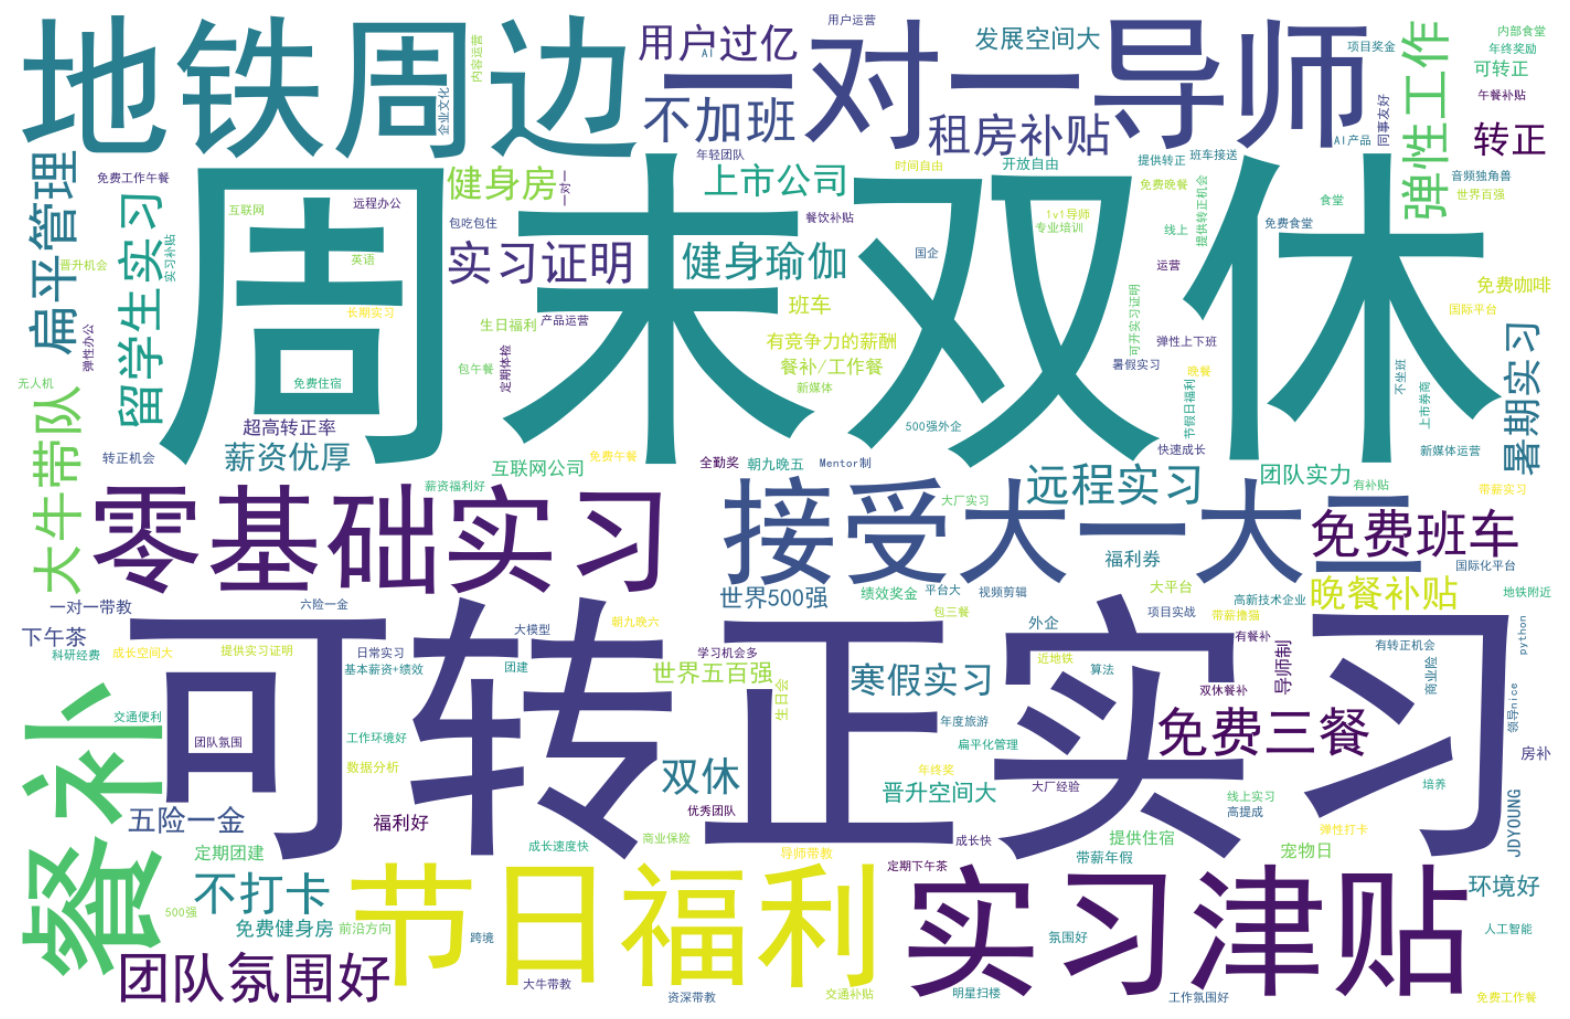

In [13]:
# 用于存放解析后的全部岗位标签
all_tags = []

# 遍历 job_tags 字段中的每一条记录
for value in df["job_tags"]:

    # 如果当前值为空值，直接跳过
    if pd.isna(value):
        continue

    # 如果当前值本身已经是列表，则直接逐个清洗后加入 all_tags
    if isinstance(value, list):
        all_tags.extend([str(x).strip() for x in value if str(x).strip()])
        continue

    # 将当前值转换为字符串，并去除首尾空格
    text = str(value).strip()

    # 如果转换后为空字符串，直接跳过
    if not text:
        continue

    # 标记当前文本是否已经被成功解析
    parsed_flag = False

    try:
        parsed = json.loads(text)

        # 如果解析结果是列表，则将列表中的标签清洗后加入 all_tags
        if isinstance(parsed, list):
            all_tags.extend([str(x).strip() for x in parsed if str(x).strip()])
            parsed_flag = True
    except Exception:
        # JSON 解析失败时不报错，继续尝试下一种解析方式
        pass

    # 如果已经成功解析，则进入下一条记录
    if parsed_flag:
        continue

    # 如果已经成功解析，则进入下一条记录
    if parsed_flag:
        continue

    # 将拆分后的非空标签加入 all_tags
    all_tags.extend([p.strip() for p in parts if p.strip()])

# 统计所有岗位标签的出现频次
tag_counter = Counter(all_tags)

font_candidates = [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc",r"C:\Windows\Fonts\simsun.ttc"]

# 保存最终可用的字体路径
font_path = None

# 从候选字体中查找第一个存在的字体文件
for fp in font_candidates:
    if os.path.exists(fp):
        font_path = fp
        break

# 如果未找到中文字体，则主动报错，提示手动设置字体路径
if font_path is None:
    raise FileNotFoundError("未找到中文字体文件，请手动设置 font_path")

# 生成词云对象
wordcloud = WordCloud(
    font_path=font_path, width=1400, height=900,  background_color="white",  max_words=180,
    collocations=False, contour_width=1, contour_color="#DDDDDD"
).generate_from_frequencies(tag_counter)


plt.figure(figsize=(13, 8))  # 绘制词云图
plt.imshow(wordcloud, interpolation="bilinear")  # 使用双线性插值显示词云，使图像边缘更平滑
plt.axis("off")  # 关闭坐标轴，使图像更适合报告展示
plt.tight_layout()
plt.show()